<a href="https://colab.research.google.com/github/gaga0321/scRNA-aging-analysis/blob/main/scRNA_aging_analysis_diaphragm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install scanpy
import scanpy as sc
adata_aging = sc.read_h5ad("tabula-muris-senis-facs-processed-official-annotations-Diaphragm.h5ad")
print(list(adata_aging.obs.columns))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 41.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 175.3/175.3 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 105.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 7.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 319.6/319.6 kB 23.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 120.8 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.

/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['distances'] to .obsp['distances'].

This is where adjacency matrices should go now.
  return AnnData(**{
/usr/local/lib/python3.12/dist-packages/anndata/_io/h5ad.py:267: FutureWarning: Moving element from .uns['neighbors']['connectivities'] to .obsp['connectivities'].

This is where adjacency matrices should go now.
  return AnnData(**{


Ages in this cohort: ['18m', '24m', '3m']

Top 5 cell types found in this tissue:
cell_ontology_class
skeletal muscle satellite cell    892
mesenchymal stem cell             494
endothelial cell                  218
B cell                            123
macrophage                         76
Name: count, dtype: int64


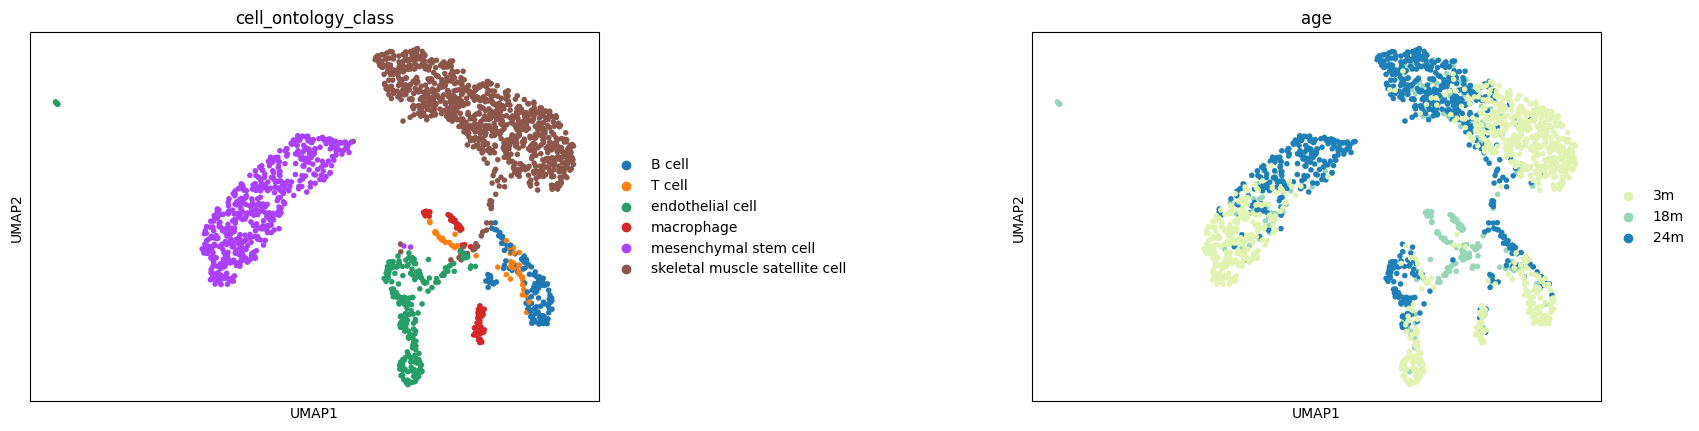

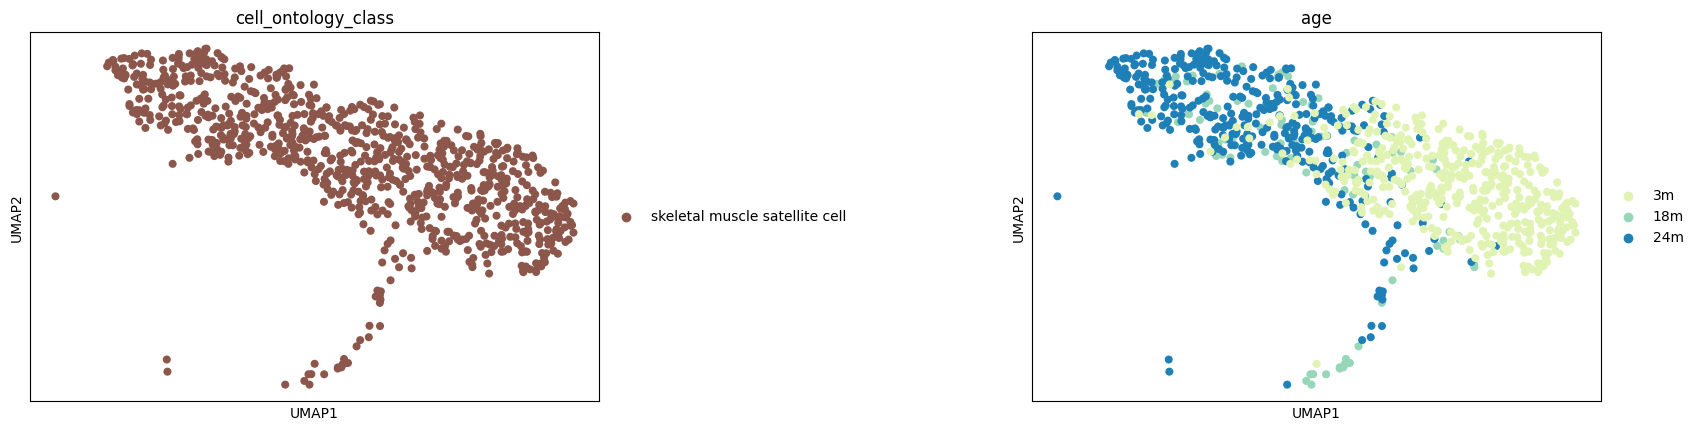

In [3]:
print("Ages in this cohort:", adata_aging.obs['age'].unique().tolist())
print("\nTop 5 cell types found in this tissue:")
print(adata_aging.obs['cell_ontology_class'].value_counts().head(5))
sc.pl.umap(adata_aging, color=['cell_ontology_class', 'age'], wspace=0.6)
skeletal_muscle_satellite_cells = adata_aging[adata_aging.obs['cell_ontology_class'] == 'skeletal muscle satellite cell'].copy()
sc.pl.umap(skeletal_muscle_satellite_cells, color=['cell_ontology_class', 'age'], wspace=0.6)

Top 10 genes upregulated in 24-month old skeletal muscle satellite cells:
    24m_n       24m_l         24m_p
0  Rpl13a         inf  1.382696e-39
1  Tmsb10  313.967987  6.144029e-29
2   Wdr89   15.369849  8.598534e-24
3     Ngp   20.734941  5.645394e-21
4  S100a8    9.287384  1.565732e-19
5   Rpl13         NaN  1.577851e-18
6     Mt1         NaN  4.091017e-17
7  S100a9    9.007737  4.679989e-17
8  Retnlg    8.718384  1.581700e-16
9    Camp    5.133050  2.076725e-16


/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: overflow encountered in expm1
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:482: RuntimeWarning: overflow encountered in expm1
  self.expm1_func(mean_rest) + 1e-9
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:481: RuntimeWarning: invalid value encountered in divide
  foldchanges = (self.expm1_func(mean_group) + 1e-9) / (
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: divide by zero encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(


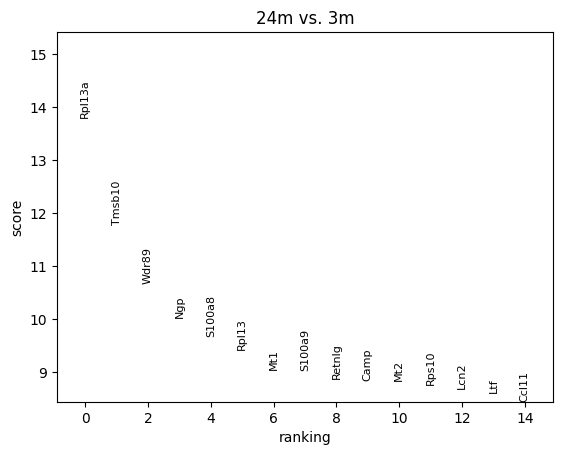

In [5]:
import pandas as pd
sc.pp.normalize_total(skeletal_muscle_satellite_cells, target_sum=1e4)
sc.pp.log1p(skeletal_muscle_satellite_cells)
sc.tl.rank_genes_groups(
    skeletal_muscle_satellite_cells,
    groupby='age',
    groups=['24m'],
    reference='3m',
    method='wilcoxon'
)
result = skeletal_muscle_satellite_cells.uns['rank_genes_groups']
groups = result['names'].dtype.names
dataframe = pd.DataFrame(
    {group + '_' + key[:1]: result[key][group]
    for group in groups for key in ['names', 'logfoldchanges', 'pvals_adj']}
)
print("Top 10 genes upregulated in 24-month old skeletal muscle satellite cells:")
print(dataframe[['24m_n', '24m_l', '24m_p']].head(10))
sc.pl.rank_genes_groups(skeletal_muscle_satellite_cells, groups=['24m'], n_genes=15, sharey=False)

In [6]:
!pip install gseapy
import gseapy as gp
import matplotlib.pyplot as plt
top_genes = dataframe['24m_n'].head(50).tolist()
print("Querying the Gene Ontology database...")
enr = gp.enrichr(
    gene_list=top_genes,
    gene_sets='GO_Biological_Process_2025',
    organism='mouse',
    outdir=None
)
results_df = enr.results
print("\nTop 5 Aging Pathways Disrupted:")
print(results_df[['Term', 'Adjusted P-value', 'Overlap']].head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 634.7/634.7 kB 12.1 MB/s eta 0:00:00
Querying the Gene Ontology database...

Top 5 Aging Pathways Disrupted:
                                              Term  Adjusted P-value Overlap
0             Cytoplasmic Translation (GO:0002181)      1.160225e-18  14/101
1  Macromolecule Biosynthetic Process (GO:0009059)      1.073732e-16  15/189
2                         Translation (GO:0006412)      6.079950e-14  14/232
3                     Gene Expression (GO:0010467)      4.303357e-11  14/381
4           Protein Metabolic Process (GO:0019538)      1.491190e-09  15/614


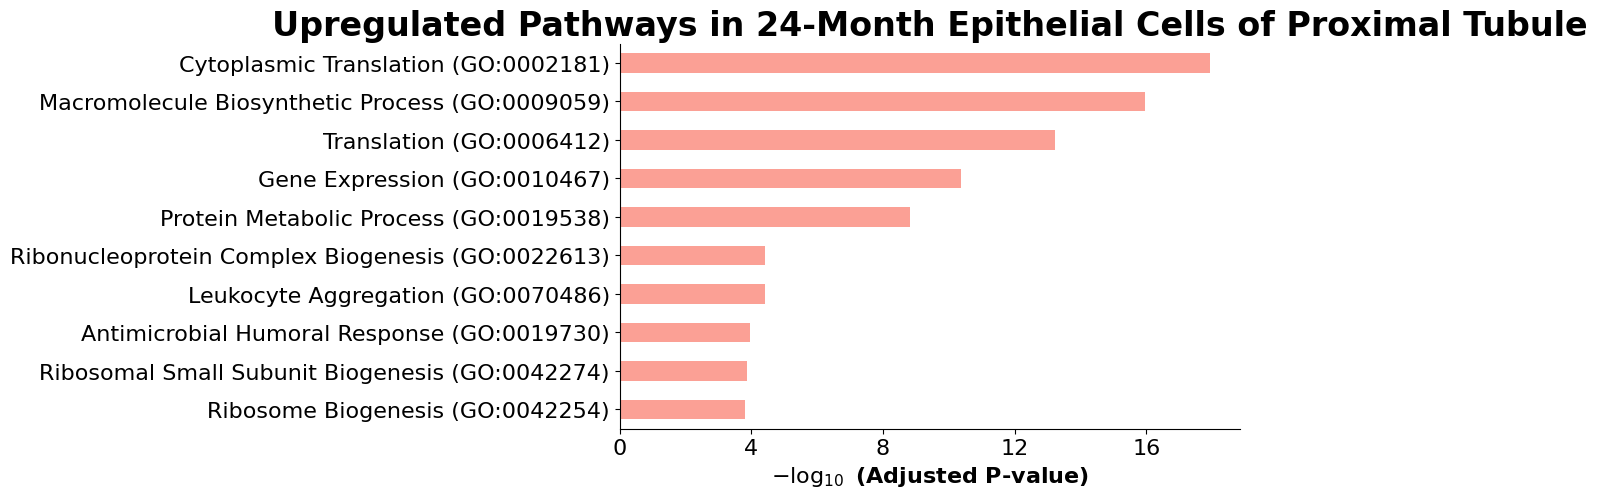

In [7]:
gp.barplot(
    enr.results,
    column="Adjusted P-value",
    title='Upregulated Pathways in 24-Month Epithelial Cells of Proximal Tubule',
    top_term=10,
    figsize=(8, 5)
)
plt.show()